# ⚛️ Notebook 05: Algoritmo de Shor — Dos Enfoques de Implementación en Qiskit

**Herramientas:** Qiskit 2.x + AerSimulator + Matplotlib  
**Objetivo:** Implementar y comparar los dos métodos de construcción del Algoritmo de Shor para factorizar $N=15$:
1. **Parte A:** Shor con QFT Inversa Manual y Multiplicador Modular paso a paso.
2. **Parte B:** Shor usando la clase abstracta de biblioteca `PhaseEstimation` de Qiskit.
**Prerequisito:** Notebook 04 (Estimación de Fase Cuántica)  
**Tiempo estimado:** 35 minutos

---

## 1. ¿Qué resuelve el Algoritmo de Shor?

El algoritmo de Shor resuelve el problema de **factorización de enteros**: dado un número compuesto $N$, encontrar sus factores primos no triviales.

### ¿Por qué es importante?
La seguridad de RSA depende de que factorizar números grandes sea computacionalmente intratable para computadores clásicos. Shor demostró en 1994 que un computador cuántico puede factorizar en tiempo **polinomial**, lo que rompería RSA.

### Idea central: Reducción a búsqueda de periodo
Shor reduce la factorización a un problema de **búsqueda de periodo (order-finding)**:

1. Elegir un entero aleatorio $a$ tal que $1 < a < N$ y $\gcd(a, N) = 1$.
2. Encontrar el **orden** $r$ de $a$ módulo $N$: el menor entero positivo tal que $a^r \equiv 1 \pmod{N}$.
3. Si $r$ es par y $a^{r/2} \not\equiv -1 \pmod{N}$, entonces:
$$\gcd(a^{r/2} - 1,\; N) \quad \text{y} \quad \gcd(a^{r/2} + 1,\; N)$$
son factores no triviales de $N$.

**La parte cuántica** es el paso 2: encontrar $r$ usando Estimación de Fase Cuántica (QPE).

## 2. Elección de parámetros: $N=15$ y $a=7$

### ¿Por qué $N = 15$?
- $15 = 3 \times 5$ es el número compuesto más pequeño que no es potencia de primo.
- Solo requiere **4 qubits** para codificar el registro de estado ($2^4 = 16 > 15$).

### ¿Por qué $a = 7$?
El valor de $a$ debe cumplir:
- $1 < a < N$: es decir, $2 \leq a \leq 14$.
- $\gcd(a, N) = 1$: $a$ debe ser **coprimo** con $N$.

Los valores coprimos con 15 son: $\{2, 4, 7, 8, 11, 13, 14\}$. Para este notebook usaremos la base $a = 7$.

Verifiquemos el orden de $a = 7$ módulo 15:

| $x$ | $7^x \bmod 15$ |
|-----|-----------------|
| 0   | 1               |
| 1   | 7               |
| 2   | 4               |
| 3   | 13              |
| 4   | 1 ← regresa a 1 |

El **orden** es $r = 4$. Como $r$ es par y $7^2 \bmod 15 = 4 \neq 14$ (es decir, $\neq N-1$), podemos extraer factores:
$$\gcd(7^2 - 1, 15) = \gcd(48, 15) = 3$$
$$\gcd(7^2 + 1, 15) = \gcd(50, 15) = 5$$

¡Recuperamos $15 = 3 \times 5$!

In [ ]:
# ------------------------------------------------------------------------------
# Notebooks 04 y 05: Estimación de Fase Cuántica (QPE) y Factorización de Shor
# ------------------------------------------------------------------------------
!pip install -q qiskit              # Creación de puertas compuestas (QFT, rotaciones de fase)
!pip install -q qiskit-aer          # Simulador para medición del vector de estado y counts
!pip install -q pylatexenc          # Visualización bonita de los circuitos complejos


## 3. Verificación clásica de los parámetros

In [13]:
from math import gcd
from fractions import Fraction

# --- Parámetros del algoritmo ---
N = 15   # Número a factorizar
a = 7   # Base coprima con N (elegida aleatoriamente en la práctica)

# Verificar que a es coprimo con N
print(f"N = {N}, a = {a}")
print(f"gcd({a}, {N}) = {gcd(a, N)}  ← debe ser 1 para usar Shor")
print()

# Calcular el orden r de a mod N (clásicamente, para verificación)
print("Secuencia a^x mod N:")
print("-" * 30)
r_clasico = None
for x in range(1, N + 1):
    val = pow(a, x, N)   # a^x mod N eficiente
    print(f"  {a}^{x} mod {N} = {val}")
    if val == 1 and r_clasico is None:
        r_clasico = x
        print(f"  ↑ Primera vez que regresa a 1 → r = {r_clasico}")

print(f"\nOrden encontrado (clásico): r = {r_clasico}")
print(f"r es par: {r_clasico % 2 == 0}")
if r_clasico % 2 == 0:
    f1 = gcd(a**(r_clasico//2) - 1, N)
    f2 = gcd(a**(r_clasico//2) + 1, N)
    print(f"Factor 1: mcd({a}^{r_clasico//2} - 1, {N}) = mcd({a**(r_clasico//2)-1}, {N}) = {f1}")
    print(f"Factor 2: mcd({a}^{r_clasico//2} + 1, {N}) = mcd({a**(r_clasico//2)+1}, {N}) = {f2}")
    print(f"\n✅ {N} = {f1} × {f2}")

N = 15, a = 7
gcd(7, 15) = 1  ← debe ser 1 para usar Shor

Secuencia a^x mod N:
------------------------------
  7^1 mod 15 = 7
  7^2 mod 15 = 4
  7^3 mod 15 = 13
  7^4 mod 15 = 1
  ↑ Primera vez que regresa a 1 → r = 4
  7^5 mod 15 = 7
  7^6 mod 15 = 4
  7^7 mod 15 = 13
  7^8 mod 15 = 1
  7^9 mod 15 = 7
  7^10 mod 15 = 4
  7^11 mod 15 = 13
  7^12 mod 15 = 1
  7^13 mod 15 = 7
  7^14 mod 15 = 4
  7^15 mod 15 = 13

Orden encontrado (clásico): r = 4
r es par: True
Factor 1: mcd(7^2 - 1, 15) = mcd(48, 15) = 3
Factor 2: mcd(7^2 + 1, 15) = mcd(50, 15) = 5

✅ 15 = 3 × 5


## 4. Importar librerías

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd
from fractions import Fraction

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, PhaseEstimation
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import qiskit
print(f"Qiskit versión: {qiskit.__version__}")

Qiskit versión: 2.2.1


# Parte A: Shor con QFT Inversa Manual

En esta sección implementamos el algoritmo de Shor a bajo nivel, construyendo explícitamente el bucle de exponenciación modular controlada qubit por qubit y aplicando la compuerta `QFT` inversa manualmente.

### 1. Definición del operador multiplicador controlado
La siguiente función `c_amod15(a, power)` genera la versión controlada del operador modular $U^{2^j} |y\rangle = |a^{2^j} \cdot y \bmod 15\rangle$. Para $a=7$, repetimos la permutación modular $U$ un total de `power` veces.

In [15]:
def c_amod15(a, power):
    """Multiplicación modular controlada: a^power mod 15.
    Retorna la compuerta controlada de 1 control que actúa sobre 4 qubits."""
    if a not in [2,7,8,11,13]:
        raise ValueError("'a' debe ser coprimo con 15 y no trivial.")
    
    U = QuantumCircuit(4)        
    for _ in range(power):
        if a in [2,13]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [7,8]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a == 11:
            U.swap(1,3)
            U.swap(0,2)
        if a in [7,11,13]:
            for q in range(4):
                U.x(q)
                
    U_gate = U.to_gate(label=f"U({a}^{power} mod 15)")
    return U_gate.control(1)

### 2. Construcción del circuito manual
Declaramos un registro de conteo de 8 qubits para alta precisión ($t=8$) y un registro objetivo de 4 qubits. Inicializamos el estado objetivo en $|1\rangle$, aplicamos Hadamards, aplicamos el bucle modular controlado, y acoplamos la QFT inversa.

C:\Users\migue\AppData\Local\Temp\ipykernel_50188\3402073606.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_inv = QFT(num_qubits=8, approximation_degree=0, do_swaps=True, inverse=True)


Circuito manual de Shor construido exitosamente.


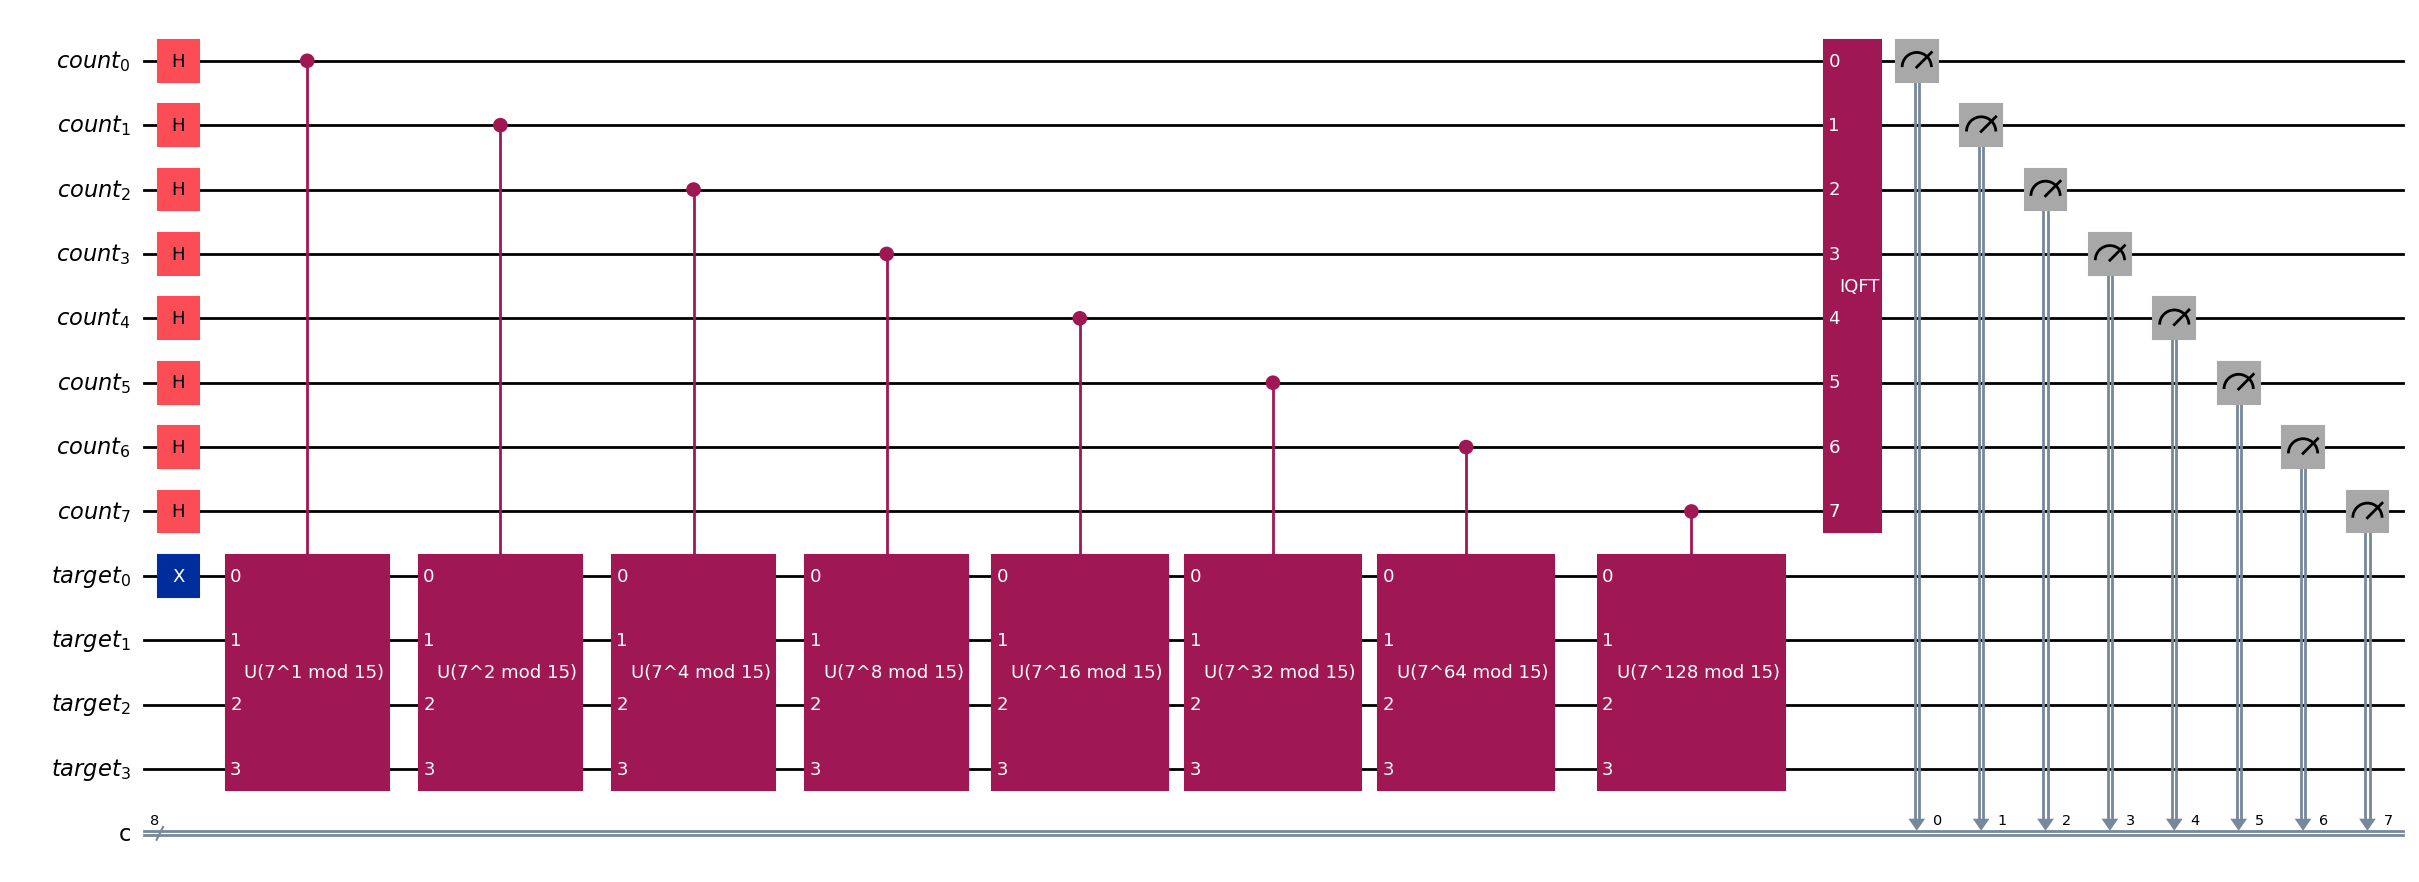

In [28]:
# Definir registros
count_reg = QuantumRegister(8, name='count')
target_reg = QuantumRegister(4, name='target')
classic_reg = ClassicalRegister(8, name='c')

qc_manual = QuantumCircuit(count_reg, target_reg, classic_reg)

# 1. Superposición en registro de conteo
qc_manual.h(count_reg)

# 2. Inicializar registro de estado en |1⟩
qc_manual.x(target_reg[0])

# 3. Aplicar multiplicación modular controlada qubit por qubit
for q in range(8):
    c_gate = c_amod15(a, 2**q)
    qc_manual.append(c_gate, [count_reg[q]] + target_reg[:])

# 4. Aplicar QFT Inversa manual sobre los qubits de conteo
qft_inv = QFT(num_qubits=8, approximation_degree=0, do_swaps=True, inverse=True)
qc_manual.append(qft_inv, count_reg)

# 5. Medir registro de conteo
qc_manual.measure(count_reg, classic_reg)

print("Circuito manual de Shor construido exitosamente.")
qc_manual.draw('mpl', fold=-1)

### 3. Simulación y resultados del método manual

Resultados de simulación (Método Manual):
----------------------------------------
  |00000000⟩ = 0 → 2539 veces (25.4%)
  |01000000⟩ = 64 → 2515 veces (25.1%)
  |10000000⟩ = 128 → 2465 veces (24.6%)
  |11000000⟩ = 192 → 2481 veces (24.8%)


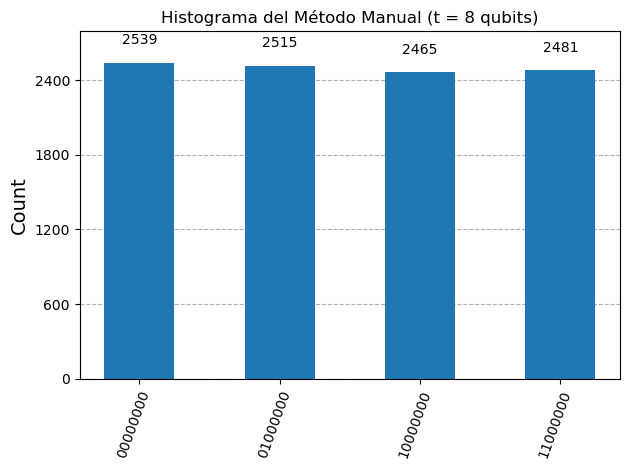

In [29]:
simulator = AerSimulator()
qc_manual_trans = transpile(qc_manual, simulator)

shots = 10000
counts_manual = simulator.run(qc_manual_trans, shots=shots).result().get_counts()

print("Resultados de simulación (Método Manual):")
print("-" * 40)
for bitstring, count in sorted(counts_manual.items()):
    prob = count / shots * 100
    print(f"  |{bitstring}⟩ = {int(bitstring, 2)} → {count:4d} veces ({prob:.1f}%)")

# Visualizar histograma
plot_histogram(counts_manual, title="Histograma del Método Manual (t = 8 qubits)")


### 4. Post-procesamiento clásico (Método Manual)
Tomamos las lecturas obtenidas y usamos fracciones continuas para extraer el período $r$ y los factores primos.

In [30]:
print(f"Post-procesamiento clásico para N = {N}, a = {a}")
print(f"Qubits de evaluación: t = 8 → 2^t = 256")
print("=" * 60)

factores_encontrados_manual = set()

# Procesar mediciones con más de 50 lecturas (evitar ruido si lo hubiera)
for medicion_bin, conteo in sorted(counts_manual.items(), key=lambda x: -x[1]):
    if conteo < 50:
        continue
    m = int(medicion_bin, 2)
    fase = m / 256
    
    fraccion = Fraction(fase).limit_denominator(N)
    r_candidato = fraccion.denominator
    s = fraccion.numerator
    
    print(f"\nMedición: |{medicion_bin}⟩ = {m} ({conteo} veces)")
    print(f"  Fase estimada: θ ≈ {fase:.4f}")
    print(f"  Fracción continua: {s}/{r_candidato}")
    print(f"  Candidato a periodo: r = {r_candidato}")
    
    if r_candidato == 0:
        print("  ⚠️ r = 0 (fase trivial), descartado.")
        continue
        
    verificacion = pow(a, r_candidato, N)
    print(f"  Verificación: {a}^{r_candidato} mod {N} = {verificacion}", end="")
    if verificacion != 1:
        print(" ❌ (inválido)")
        continue
    print(" ✅")
    
    if r_candidato % 2 != 0:
        print(f"  ⚠️ r={r_candidato} es impar, no aporta factores.")
        continue
        
    half_power = pow(a, r_candidato // 2, N)
    if half_power == N - 1:
        print(f"  ⚠️ {a}^{r_candidato//2} mod {N} = {half_power} = N-1, caso trivial.")
        continue
        
    f1 = gcd(int(a**(r_candidato // 2)) - 1, N)
    f2 = gcd(int(a**(r_candidato // 2)) + 1, N)
    
    if f1 not in (1, N):
        factores_encontrados_manual.add(f1)
    if f2 not in (1, N):
        factores_encontrados_manual.add(f2)
    print(f"  → Factores no triviales encontrados: {f1} y {f2}")

print("\n" + "=" * 60)
print(f"Factores recuperados del método manual: {factores_encontrados_manual}")


Post-procesamiento clásico para N = 15, a = 7
Qubits de evaluación: t = 8 → 2^t = 256

Medición: |00000000⟩ = 0 (2539 veces)
  Fase estimada: θ ≈ 0.0000
  Fracción continua: 0/1
  Candidato a periodo: r = 1
  Verificación: 7^1 mod 15 = 7 ❌ (inválido)

Medición: |01000000⟩ = 64 (2515 veces)
  Fase estimada: θ ≈ 0.2500
  Fracción continua: 1/4
  Candidato a periodo: r = 4
  Verificación: 7^4 mod 15 = 1 ✅
  → Factores no triviales encontrados: 3 y 5

Medición: |11000000⟩ = 192 (2481 veces)
  Fase estimada: θ ≈ 0.7500
  Fracción continua: 3/4
  Candidato a periodo: r = 4
  Verificación: 7^4 mod 15 = 1 ✅
  → Factores no triviales encontrados: 3 y 5

Medición: |10000000⟩ = 128 (2465 veces)
  Fase estimada: θ ≈ 0.5000
  Fracción continua: 1/2
  Candidato a periodo: r = 2
  Verificación: 7^2 mod 15 = 4 ❌ (inválido)

Factores recuperados del método manual: {3, 5}


# Parte B: Shor con la clase `PhaseEstimation` de Qiskit

En esta sección utilizamos la clase de biblioteca `PhaseEstimation` de Qiskit para construir la estimación de fase directamente sobre el operador unitario base $U$, abstrayendo Hadamards, potencias controladas y la QFT inversa en un único bloque modular.

### 1. Construcción de la Compuerta Unitaria base $U$
Definimos el operador modular cíclico $U|y\rangle = |7y \bmod 15\rangle$ en 4 qubits usando 3 SWAPs y 4 compuertas NOT (X).

Operador U construido como compuerta unitaria.


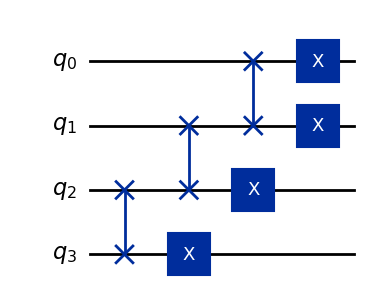

In [19]:
# El operador unitario base actúa sobre 4 qubits
U_qc = QuantumCircuit(4, name="U=7mod15")

# 1. SWAPs en cascada (permutación circular de bits)
U_qc.swap(2, 3)
U_qc.swap(1, 2)
U_qc.swap(0, 1)

# 2. Inversión de bits
for q in range(4):
    U_qc.x(q)

U_gate = U_qc.to_gate(label="U(7mod15)")
print("Operador U construido como compuerta unitaria.")
U_qc.draw('mpl')

### 2. Ensamblado del circuito con PhaseEstimation
Utilizamos $t=3$ qubits de evaluación y conectamos la unitaria $U$ en la clase de alto nivel `PhaseEstimation`.

C:\Users\migue\AppData\Local\Temp\ipykernel_50188\914319345.py:3: DeprecationWarning: The class ``qiskit.circuit.library.phase_estimation.PhaseEstimation`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.phase_estimation instead.
  qpe_circuit = PhaseEstimation(


Circuito QPE de Shor (PhaseEstimation) ensamblado exitosamente.


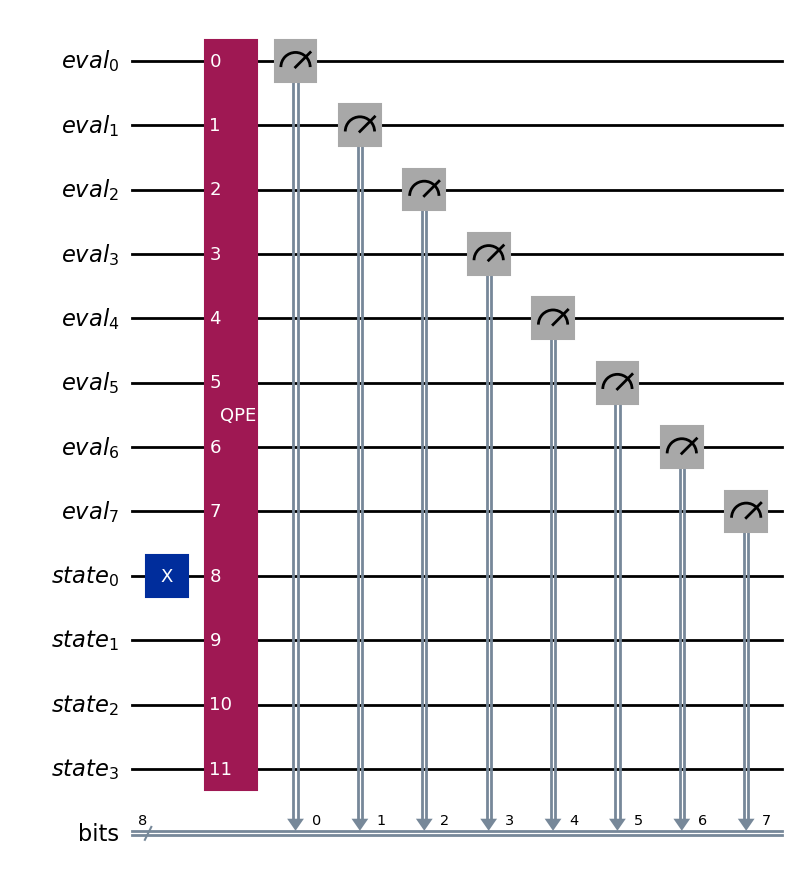

In [20]:
# Instanciar PhaseEstimation
num_eval_qubits = 8
qpe_circuit = PhaseEstimation(
    num_evaluation_qubits=num_eval_qubits,  # t = 3 (precisión de fase)
    unitary=U_gate                           # Operador unitario U
)

# Declarar registros
qr_eval = QuantumRegister(num_eval_qubits, 'eval')
qr_state = QuantumRegister(4, 'state')
cr = ClassicalRegister(num_eval_qubits, 'bits')

qc_qpe = QuantumCircuit(qr_eval, qr_state, cr)

# Inicializar estado en |1⟩ (qubit 0 del registro de estado)
qc_qpe.x(qr_state[0])

# Acoplar el bloque QPE
qc_qpe.append(qpe_circuit, qr_eval[:] + qr_state[:])

# Medir qubits de evaluación
qc_qpe.measure(qr_eval, cr)

print("Circuito QPE de Shor (PhaseEstimation) ensamblado exitosamente.")
qc_qpe.draw('mpl')

### 3. Simulación y resultados (PhaseEstimation)

Resultados de simulación (PhaseEstimation Qiskit):
---------------------------------------------
  |00000000⟩ = 0 → 2448 veces (24.5%)
  |00000001⟩ = 1 → 2489 veces (24.9%)
  |00000010⟩ = 2 → 2514 veces (25.1%)
  |00000011⟩ = 3 → 2549 veces (25.5%)


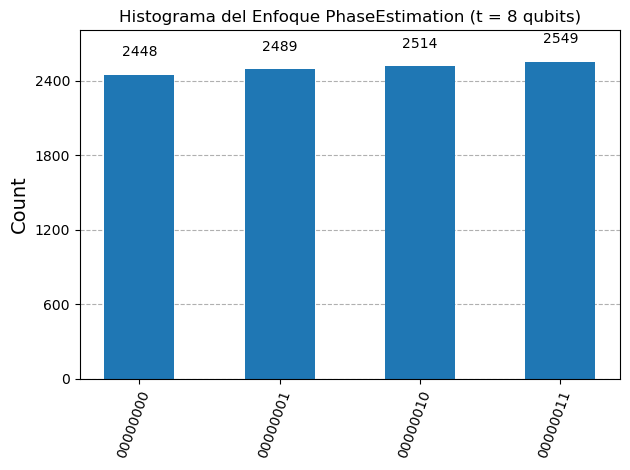

In [25]:
qc_qpe_trans = transpile(qc_qpe, simulator)
counts_qpe = simulator.run(qc_qpe_trans, shots=shots).result().get_counts()

print("Resultados de simulación (PhaseEstimation Qiskit):")
print("-" * 45)
for bitstring, count in sorted(counts_qpe.items()):
    prob = count / shots * 100
    print(f"  |{bitstring}⟩ = {int(bitstring, 2)} → {count:4d} veces ({prob:.1f}%)")

plot_histogram(counts_qpe, title="Histograma del Enfoque PhaseEstimation (t = 8 qubits)")

### 4. Post-procesamiento clásico (PhaseEstimation)

In [26]:
print(f"Post-procesamiento clásico para N = {N}, a = {a}")
print(f"Qubits de evaluación: t = 3 → 2^t = 8")
print("=" * 60)

factores_encontrados_qpe = set()

for medicion_bin, conteo in sorted(counts_qpe.items(), key=lambda x: -x[1]):
    if conteo < 50:
        continue
    m = int(medicion_bin, 2)
    fase = m / 8
    
    fraccion = Fraction(fase).limit_denominator(N)
    r_candidato = fraccion.denominator
    s = fraccion.numerator
    
    print(f"\nMedición: |{medicion_bin}⟩ = {m} ({conteo} veces)")
    print(f"  Fase estimada: θ ≈ {fase:.4f}")
    print(f"  Fracción continua: {s}/{r_candidato}")
    print(f"  Candidato a periodo: r = {r_candidato}")
    
    if r_candidato == 0:
        print("  ⚠️ r = 0, descartado.")
        continue
        
    verificacion = pow(a, r_candidato, N)
    print(f"  Verificación: {a}^{r_candidato} mod {N} = {verificacion}", end="")
    if verificacion != 1:
        print(" ❌ (inválido)")
        continue
    print(" ✅")
    
    if r_candidato % 2 != 0:
        print(f"  ⚠️ r={r_candidato} es impar, no aporta factores.")
        continue
        
    half_power = pow(a, r_candidato // 2, N)
    if half_power == N - 1:
        print(f"  ⚠️ {a}^{r_candidato//2} mod {N} = {half_power} = N-1, caso trivial.")
        continue
        
    f1 = gcd(int(a**(r_candidato // 2)) - 1, N)
    f2 = gcd(int(a**(r_candidato // 2)) + 1, N)
    
    if f1 not in (1, N):
        factores_encontrados_qpe.add(f1)
    if f2 not in (1, N):
        factores_encontrados_qpe.add(f2)
    print(f"  → Factores no triviales encontrados: {f1} y {f2}")

print("\n" + "=" * 60)
print(f"Factores recuperados con PhaseEstimation: {factores_encontrados_qpe}")

Post-procesamiento clásico para N = 15, a = 7
Qubits de evaluación: t = 3 → 2^t = 8

Medición: |00000011⟩ = 3 (2549 veces)
  Fase estimada: θ ≈ 0.3750
  Fracción continua: 3/8
  Candidato a periodo: r = 8
  Verificación: 7^8 mod 15 = 1 ✅
  → Factores no triviales encontrados: 15 y 1

Medición: |00000010⟩ = 2 (2514 veces)
  Fase estimada: θ ≈ 0.2500
  Fracción continua: 1/4
  Candidato a periodo: r = 4
  Verificación: 7^4 mod 15 = 1 ✅
  → Factores no triviales encontrados: 3 y 5

Medición: |00000001⟩ = 1 (2489 veces)
  Fase estimada: θ ≈ 0.1250
  Fracción continua: 1/8
  Candidato a periodo: r = 8
  Verificación: 7^8 mod 15 = 1 ✅
  → Factores no triviales encontrados: 15 y 1

Medición: |00000000⟩ = 0 (2448 veces)
  Fase estimada: θ ≈ 0.0000
  Fracción continua: 0/1
  Candidato a periodo: r = 1
  Verificación: 7^1 mod 15 = 7 ❌ (inválido)

Factores recuperados con PhaseEstimation: {3, 5}


## 10. Comparativa de Enfoques

| Característica | Parte A: Manual | Parte B: PhaseEstimation |
|----------------|-----------------|--------------------------|
| **Qubits de conteo** | $t=8$ (Mayor resolución) | $t=3$ (Mínimo necesario para N=15) |
| **Construcción de CU** | Bucle manual de potencias controladas | Encapsulado por Qiskit |
| **Abstracción de QFT** | Compuerta `QFT(inverse=True)` añadida manualmente | Automática dentro del bloque |
| **Objetivo didáctico** | Entender la secuencia de interferencia y paso a paso | Conocer las bibliotecas estandarizadas modernas |

---


## Modelo de código para simulador de cualquier N hasta 7 Bits empleando QFT Inversa

In [31]:
#Funcion Coprimos 
import math
import random

def encontrar_coprimo_automatico(N: int) -> int:
    """
    Busca de forma automática un valor 'a' que sea coprimo con N.
    Si de casualidad encuentra un factor directo, lo avisa de inmediato.
    """
    # 1. Validación rápida para evitar bucles infinitos
    if N % 2 == 0:
        print(f"⚠️ Nota: N={N} es par. Su factor obvio es 2. ¡No necesitas Shor!")
        return 2
        
    intentos = 0
    while intentos < 1000:
        # Elegir un número aleatorio entre 2 y N-1
        a = random.randint(2, N - 1)
        
        # Calcular el Máximo Común Divisor (MCD) usando el algoritmo de Euclides
        mcd = math.gcd(a, N)
        
        if mcd == 1:
            # Encontrado: 'a' y 'N' son coprimos, listos para el circuito cuántico
            print(f"🎯 Coprimo encontrado con éxito: a = {a} (mcd({a}, {N}) = 1)")
            return a
        elif mcd > 1:
            # Caso fortuito: El número aleatorio ya era un factor de N clásicamente
            print(f"🎉  Se encontró un factor directo de {N} sin usar el circuito cuántico: {mcd}")
            return a
            
    raise ValueError(f"No se pudo encontrar un coprimo para N={N} tras muchos intentos.")


🎯 Coprimo encontrado con éxito: a = 20 (mcd(20, 27) = 1)
⚙️ Configurando Shor con UnitaryGate:
   • Qubits de Análisis (Target): 5
   • Qubits de Observación (Conteo): 10
   • Total de qubits en el circuito: 15


C:\Users\migue\AppData\Local\Temp\ipykernel_50188\4138152891.py:73: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_inv = QFT(num_qubits=len(count_reg), approximation_degree=0, do_swaps=True, inverse=True).to_gate()



🚀 ¡Simulación finalizada! Los picos de frecuencia han despertado.

ANÁLISIS DE FRACCIONES CONTINUAS PARA N = 27, a = 20
Denominador de precisión cuántica (2^t): 1024

Medición: |1000000000⟩ =  512 (294 veces)
  -> Fase aproximada: φ ≈ 0.5000
  -> Fracción correspondiente: 1/2
  -> Período candidato extraído: r = 2
  -> Verificación clásica: 20^2 mod 27 = 22 ❌ (Período inválido)

Medición: |0000111001⟩ =   57 (268 veces)
  -> Fase aproximada: φ ≈ 0.0557
  -> Fracción correspondiente: 1/18
  -> Período candidato extraído: r = 18
  -> Verificación clásica: 20^18 mod 27 = 1 ✅ (Período matemático real)
  ⚠️ Raíz modular da caso trivial: 26

Medición: |0111000111⟩ =  455 (267 veces)
  -> Fase aproximada: φ ≈ 0.4443
  -> Fracción correspondiente: 4/9
  -> Período candidato extraído: r = 9
  -> Verificación clásica: 20^9 mod 27 = 26 ❌ (Período inválido)

Medición: |1111000111⟩ =  967 (261 veces)
  -> Fase aproximada: φ ≈ 0.9443
  -> Fracción correspondiente: 17/18
  -> Período candidato extra

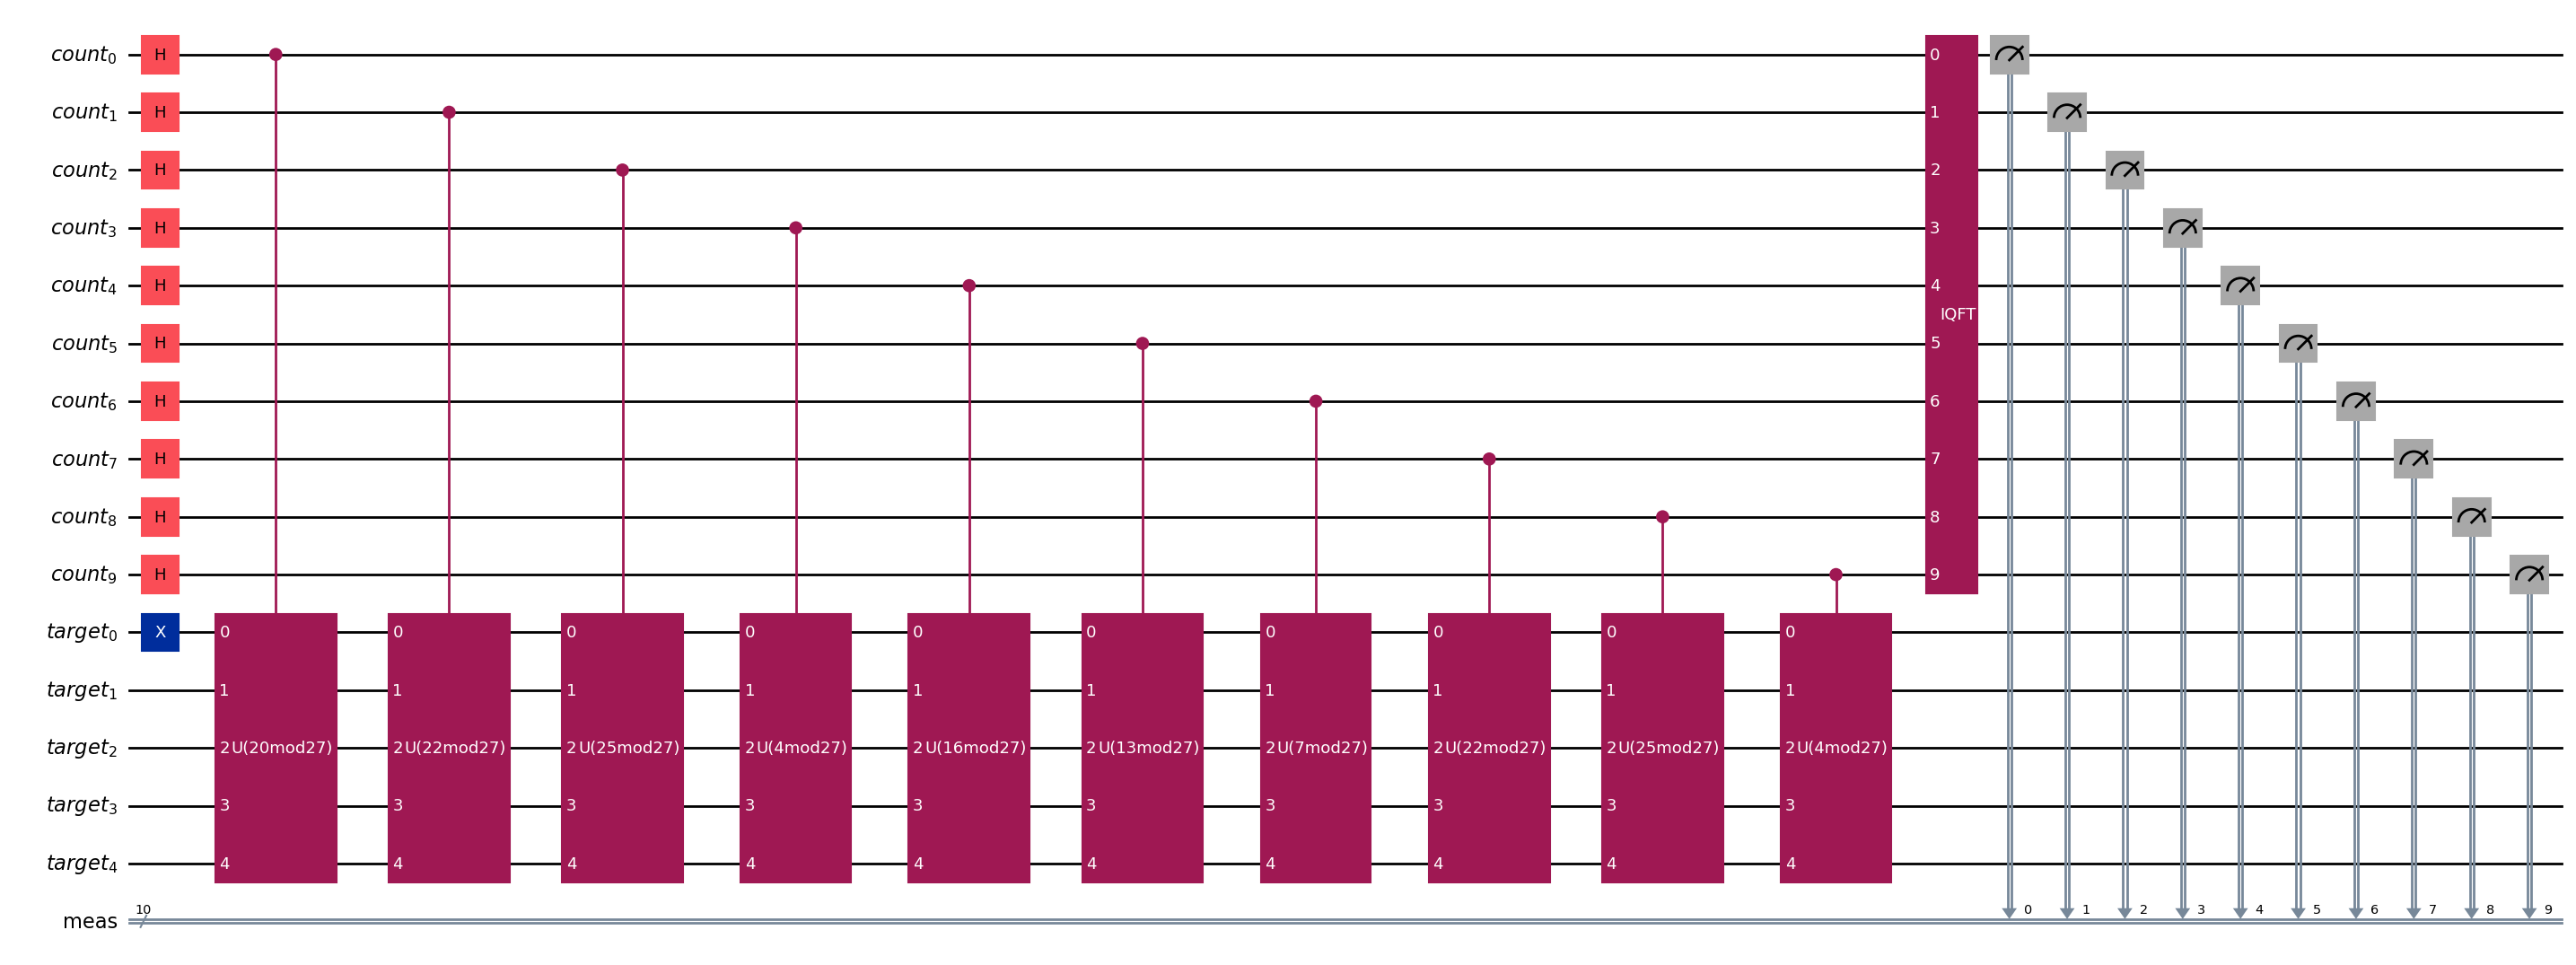

In [45]:
N = 27
#SHOR MEDIANTE QFT INVERSA Y UNITARY GATE
import numpy as np
import math
from fractions import Fraction
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, QFT
from qiskit_aer import AerSimulator
from qiskit import transpile

# =====================================================================
# 1. PARÁMETROS DEL ALGORITMO (Cambia N y 'a' por el número que desees)
# =====================================================================

a = encontrar_coprimo_automatico(N) # Debe ser coprimo con N (mcd(a, N) == 1)
shots = 5000
# =====================================================================
# 2. FUNCIONES DE CONSTRUCCIÓN DEL CIRCUITO CUÁNTICO
# =====================================================================
def crear_operador_u_universal(a: int, N: int, num_bits_target: int):
    """
    Construye la compuerta U base resolviendo el Endianness de Qiskit
    mediante una permutación binaria invertida clásica en la CPU.
    """
    dimension = 2 ** num_bits_target
    matriz_u = np.zeros((dimension, dimension))
    
    for x in range(dimension):
        if x < N:
            y = (a * x) % N
        else:
            y = x  # Identidad para estados fuera del módulo
            
        # TRUCO DEL ENDIANNESS: Invertimos los bits de los índices clásicos 
        # antes de guardarlos en la matriz. Así Qiskit los lee de forma nativa.
        x_bin_rev = int(f"{x:0{num_bits_target}b}"[::-1], 2)
        y_bin_rev = int(f"{y:0{num_bits_target}b}"[::-1], 2)
        
        matriz_u[y_bin_rev, x_bin_rev] = 1.0
        
    return UnitaryGate(matriz_u, label=f"U({a}mod{N})")

def exponenciacion_modular_shor_unitary(a: int, N: int):
    """Orquesta el QPE usando la cascada de UnitaryGates optimizadas."""
    num_bits_target = (N - 1).bit_length()  # Espacio para almacenar el número N
    num_bits_conteo = 2 * num_bits_target   # Doble de qubits para máxima precisión
    
    print(f"⚙️ Configurando Shor con UnitaryGate:")
    print(f"   • Qubits de Análisis (Target): {num_bits_target}")
    print(f"   • Qubits de Observación (Conteo): {num_bits_conteo}")
    print(f"   • Total de qubits en el circuito: {num_bits_target + num_bits_conteo}")
    
    count_reg = QuantumRegister(num_bits_conteo, name='count')
    target_reg = QuantumRegister(num_bits_target, name='target')
    classic_reg = ClassicalRegister(num_bits_conteo, name='meas')
    
    qc = QuantumCircuit(count_reg, target_reg, classic_reg)
    
    # Inicialización estándar
    qc.h(count_reg)       
    qc.x(target_reg[0])  # Inicializa estrictamente el estado en |1> real
    
    # Cascada de operadores controlados
    for j in range(num_bits_conteo):  
        potencia_clasica = pow(a, 2**j, N)
        sub_compuerta = crear_operador_u_universal(potencia_clasica, N, num_bits_target)
        compuerta_controlada = sub_compuerta.control(1)
        
        qubits_a_conectar = [count_reg[j]] + list(target_reg)
        qc.append(compuerta_controlada, qubits_a_conectar)
        
    # QFT Inversa parametrizada
    qft_inv = QFT(num_qubits=len(count_reg), approximation_degree=0, do_swaps=True, inverse=True).to_gate()
    qc.append(qft_inv, count_reg)
    qc.measure(count_reg, classic_reg)
    
    return qc

# =====================================================================
# 3. EJECUCIÓN DE LA SIMULACIÓN CUÁNTICA
# =====================================================================
if math.gcd(a, N) != 1:
    print(f"❌ {a} y {N} no son coprimos. Factor encontrado clásicamente: {math.gcd(a, N)}")
else:
    circuito_shor_completo = exponenciacion_modular_shor_unitary(a, N)
    simulator = AerSimulator()
    qc_trans = transpile(circuito_shor_completo, simulator)
    
    
    counts_qpe = simulator.run(qc_trans, shots=shots).result().get_counts()
    print("\n🚀 ¡Simulación finalizada! Los picos de frecuencia han despertado.")

    # =====================================================================
    # 4. POST-PROCESAMIENTO CLÁSICO DE FRACCIONES CONTINUAS (EXTRACTOR)
    # =====================================================================
    bitstring_muestra = list(counts_qpe.keys())[0]
    num_bits_conteo = len(bitstring_muestra)
    potencia_dos_t = 2 ** num_bits_conteo

    print("\n" + "=" * 60)
    print(f"ANÁLISIS DE FRACCIONES CONTINUAS PARA N = {N}, a = {a}")
    print(f"Denominador de precisión cuántica (2^t): {potencia_dos_t}")
    print("=" * 60)

    factores_encontrados_shor = set()
    umbral_minimo = max(5, int(shots * 0.02))  # Filtrar ruido menor al 2%

    for bitstring, conteo in sorted(counts_qpe.items(), key=lambda item: -item[1]):
        if conteo < umbral_minimo:
            continue
            
        m = int(bitstring, 2)
        fase = m / potencia_dos_t
        
        if m == 0:
            print(f"\nMedición: |{bitstring}⟩ = {m} ({conteo} veces) → Fase φ = 0.0000 (Trivial, se descarta)")
            continue

        # Algoritmo de fracciones continuas aproximando por N
        fraccion = Fraction(fase).limit_denominator(N)
        s = fraccion.numerator
        r_candidato = fraccion.denominator
        
        print(f"\nMedición: |{bitstring}⟩ = {m:4d} ({conteo} veces)")
        print(f"  -> Fase aproximada: φ ≈ {fase:.4f}")
        print(f"  -> Fracción correspondiente: {s}/{r_candidato}")
        print(f"  -> Período candidato extraído: r = {r_candidato}")
        
        # Validación del periodo
        verificacion = pow(a, r_candidato, N)
        print(f"  -> Verificación clásica: {a}^{r_candidato} mod {N} = {verificacion}", end="")
        
        if verificacion != 1:
            print(" ❌ (Período inválido)")
            continue
        print(" ✅ (Período matemático real)")
        
        # Shor exige r par
        if r_candidato % 2 != 0:
            print(f"  ⚠️ El período r={r_candidato} es impar. No se puede dividir.")
            continue
            
        # Calcular raíces modulares de forma segura
        raiz_modular = pow(a, r_candidato // 2, N)
        if raiz_modular == 1 or raiz_modular == (N - 1):
            print(f"  ⚠️ Raíz modular da caso trivial: {raiz_modular}")
            continue
            
        # Extraer factores no triviales con el MCD
        factor_1 = math.gcd(raiz_modular - 1, N)
        factor_2 = math.gcd(raiz_modular + 1, N)
        
        if factor_1 not in (1, N):
            factores_encontrados_shor.add(factor_1)
        if factor_2 not in (1, N):
            factores_encontrados_shor.add(factor_2)
            
        print(f"  🎯 ¡Factores no triviales extraídos en este pico: {factor_1} y {factor_2}")

    print("\n" + "=" * 60)
    if factores_encontrados_shor:
        print(f"🎉 FACTORES PRIMOS FINALES ENCONTRADOS: {list(factores_encontrados_shor)}")
    else:
        print("❌ No se pudieron recuperar factores válidos. Intenta con otra base 'a'.")
    print("=" * 60)
circuito_shor_completo.draw('mpl', fold=-1)